In [1]:
# @title library installation

import numpy as np
import matplotlib.pyplot as plt
try:
     import dlroms.fespaces as fe
except:
     !pip install git+https://github.com/NicolaRFranco/dlroms.git
     import dlroms.fespaces as fe
from refrigerator import FOMsolver,Vh

# **Projects - Part 2 - Thermal Refrigerator**


We consider a channel $\Omega_\delta \subset \mathbb{R}^2$ of width $\delta > 0$, wrapped around a rectangular bulk $\Omega_b \subset \mathbb{R}^2$, such that

$$
\Omega := \Omega_\delta \cup \Omega_b = (0, 1)^2;
$$

see Figure 1 for a visual representation and a precise definition of the two domains.

At time $t = 0$, the system is in thermal equilibrium, with a normalized temperature of $u_0 \equiv 1$. As time begins to flow, a refrigerant starts to circulate through the pipe $\Omega_\delta$, entering from the small gate at the bottom-left corner. The refrigerant moves through the channel transported by a laminar fluid of velocity $\beta$. We model the latter as the steady state solution of the following Stokes’ equation,

$$
\begin{cases}
-10^2 \Delta \beta - \nabla p = 0 & \text{in } \Omega_\delta \\
\nabla \cdot \beta = 0 & \text{in } \Omega_\delta,
\end{cases}
$$

complemented with boundary conditions $\beta = 0$ on $\Gamma_{\text{walls}}$, $p = 0$ on $\Gamma_{\text{out}}$ and $\beta = \beta_0$ on $\Gamma_{\text{in}}$, where

$$
\beta_0(x, y) := \frac{1}{10 \delta^3} [y(\delta - y), 0]^\top.
$$

Being in contact with the pipe, as the refrigerant comes in, the bulk begins to cool down. Let $u : \Omega \times [0, T] \to [0, 1]$ denote the normalized temperature across the pipe and the bulk at a given time. We model the latter as

$$
\begin{cases}
\frac{\partial u}{\partial t} - \nabla \cdot (\sigma_{D,d} \nabla u) + 1_{\Omega_\delta} \beta \cdot \nabla u = 0 & \text{in } \Omega \times (0, T) \\
-\nabla u \cdot n = 0 & \text{on } (\partial \Omega \setminus \Gamma_{\text{in}}) \times (0, T) \\
u(\cdot, t) = e^{-t} & \text{on } \Gamma_{\text{in}} \times (0, T) \\
u(\cdot, 0) = 1 & \text{in } \Omega.
\end{cases}
$$

Here, $\sigma_{D,d}$ is a piecewise constant conductivity field modeling the structural differences between the channel and the bulk. More precisely,

$$
\sigma_{D,d}(x, y) =
\begin{cases}
D & \text{if } (x, y) \in \Omega_\delta \\
d & \text{if } (x, y) \in \Omega_b.
\end{cases}
$$


# Tasks

1)
Let $\mu := [\delta, D, d]$. Sample a suitable number of random FOM simulations by letting $0.05 \leq \delta \leq 0.1$, $1 \leq D \leq 5$, $0.02 \leq d \leq 0.08$. Assemble the snapshot matrix and study the singular values’ decay. Decide whether to implement a POD-NN or a DL-ROM, motivating your choice.

2)
Implement the chosen approach. In doing so, notice that the reduced network $\phi$, mapping problem configurations onto reduced/latent representations, must receive both the model parameters $\mu$ as well as the time variable $t$. Quantify the performances of the ROM solver in terms of efficiency (computational time) and accuracy. For the latter, you may refer to the following metric,

$$
\text{Error} =
\frac{1}{N_{\text{test}}}
\sum_{i=1}^{N_{\text{test}}}
\frac{\sum_{j=1}^{N_t} \|u_{\mu_i,t_j} - \tilde{u}_{\mu_i,t_j} \|}
{\sum_{j=1}^{N_t} \|u_{\mu_i,t_j} \|},
$$

where $N_t$ is the number of time instants, $\| \cdot \|$ is the Euclidean norm, $u_{\mu_i,t_j}$ is the FOM solution for parameters $\mu_i$ at time $t_j$, whereas $\tilde{u}_{\mu_i,t_j}$ denotes the corresponding ROM approximation.

3)
Let $d = 0.04$. We would like to design the pipe, in terms of width and material, to maximize the efficacy of the cooling process while simultaneously minimizing the production cost. Given $\delta > 0$, let $A_\delta$ be the area of $\Omega_\delta$. We model the production cost as

$$
\text{cost}(\delta, D) := A_\delta \cdot D,
$$

meaning that we assume diffusive materials to be more expensive to manufacture. Conversely, we model the cooling efficacy as

$$
\text{eff}(\delta, D, d) := \frac{\text{Area} \{(x, y) \in \Omega_b : u_{\delta,D,d}(x, y, T) < 0.2\}}
{\text{Area} (\Omega_b)},
$$

In other words, $\text{eff}(\delta, D, d)$ measures the proportion of the bulk $\Omega_b$ for which the final temperature $u(\cdot, T)$ is below a given threshold, here fixed to 0.2. In particular, the efficacy is maximized whenever $u < 0.2$ for all points in $\Omega_b$.

With these definitions, exploit the ROM to estimate the optimal parameters

$$
\delta^*, D^* := \arg \max_{\delta,D} \frac{\text{eff}(\delta, D, d)}{\text{cost}(\delta, D)}
$$


# **Task 1**

In order to compute the POD basis $V$, singular value decomposition of the snapshots matrix can be performed.

In practice, this can be achieved by running the FOM solver $n_s$ times to collect $n_s$ different simulations (trajectories)
$[\mathbf{u}_{1},\dots, \mathbf{u}_{n_s}]$,
for a randomly selected set of parameters:
0.05 ≤ $\delta$ ≤ 0.1, 1 ≤ D ≤ 5, 0.02 ≤ d ≤ 0.08.
Then, we can collect all the simulations in a matrix (called **snapshots matrix**)
$$\mathbf{S}=[\mathbf{u}_{h}(t_1,\mu_1),\dots, \mathbf{u}_{h}(t_{N_t},\mu_{n_s})]\in\mathbb{R}^{N_{h}\times (n_s\times N_t)}$$

of which we perform an SVD decomposition,

$$\mathbf{X}\mathbf{\Sigma}\mathbf{Y}^{\top}=\mathbf{S}$$

 $\mathbf{V}$ is defining by picking the first $n$ columns of $\mathbf{X}$.

## Snapshots computation


In [18]:
import random
def sampler(seed):
  np.random.seed(seed)
  delta = np.random.uniform(0.05,0.1)
  D = np.random.uniform(1,5)
  d = np.random.uniform(0.02,0.08)
  u = FOMsolver(delta,D,d)
  return delta,D,d,u

nsim = 300
deltaList = []
DList = []
dList = []
uList = []
for j in range(nsim):
  delta,D,d,u = sampler(j)
  deltaList.append(delta)
  DList.append(D)
  dList.append(d)
  uList.append(u)
u = np.stack(uList)
HPIPE = np.stack(deltaList)
DPIPE = np.stack(DList)
DBULK = np.stack(dList)
mu = np.column_stack((HPIPE, DPIPE, DBULK))


## Data shape
number of trajectories, parameters, domain dimension

In [19]:
nh = Vh.dim()
ndata = nsim
ntimes = 101
p = mu.shape[-1]
print("Trajectories:\t%d." % ndata)
print("Timesteps:\t%d." % ntimes)
print("FOM dimension:\t%d." % nh)
print("Parameters:\t%d." % p)

Trajectories:	300.
Timesteps:	101.
FOM dimension:	6561.
Parameters:	3.


## Data reshape

In [20]:
from dlroms import*
MU, U = CPU.tensor(mu), CPU.tensor(u)
MUT = dv.zeros(ndata, ntimes, p+1)
timesteps = CPU.tensor(np.linspace(0, 5.0, ntimes))
for i in range(ndata):
    MUT[i,:,:3] = MU[i]
    MUT[i,:, 3] = timesteps
MUT2 = MUT[100:,:,:]
U1 = U[:100,:,:]
U2 = U[100:,:,:]
U = U.reshape(-1, nh)
MUT = MUT.reshape(-1, p+1)
U1 = U1.reshape(-1, nh)
U2 = U2.reshape(-1, nh)
MUT2 = MUT2.reshape(-1, p+1)
U.shape,MUT.shape,U1.shape,U2.shape,MUT2.shape

(torch.Size([30300, 6561]),
 torch.Size([30300, 4]),
 torch.Size([10100, 6561]),
 torch.Size([20200, 6561]),
 torch.Size([20200, 4]))

## SVD
After performing the SVD of the Snapshots matrix S it's possible to plot the Singular Values decay. The decay is quite fast, meaning that the number of POD basis selected will be small.



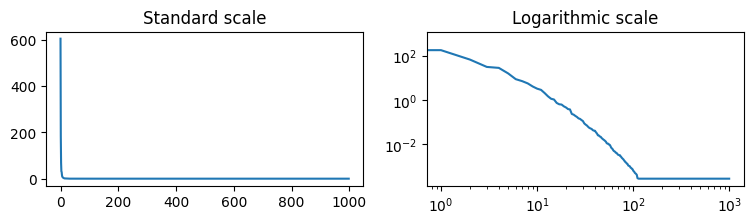

In [21]:
from scipy.linalg import svd
X, s, Yt = svd(U1.T.cpu().numpy(), full_matrices = False)
import matplotlib.pyplot as plt
plt.figure(figsize = (9, 2))
plt.subplot(1,2,1)
plt.plot(s[1:1000])
plt.title("Standard scale")
plt.subplot(1,2,2)
plt.loglog(s[1:1000])
plt.title("Logarithmic scale")
plt.show()

## POD basis

In [22]:
n = 10
V = X[:, :n]
from dlroms import*

V = CPU.tensor(V)
Uproj = U1 @ V @ V.T
avg_proj_error = mre(euclidean)(U1, Uproj)
print("Average projection error: %s." % num2p(avg_proj_error))

Average projection error: 0.18%.


The problem is easily reducible, because the singular values have a fast decay. POD-NN is the best choice: using POD for the dimensionality reduction due to the small number of POD modes selected and Neural Networks to learn a map from parameters to solutions in the reduced space.
The algorithm can be synthesized as follows:

- Collect FOM snapshots and build the snapshots matrix $S$ of dimension $\mathbb{R}^{N_h\times(N_s\times N_t)}$

- Compute the POD basis $\mathbf{V}$ via SVD of the snapshots matrix

- Construct a new dataset $\{\boldsymbol{\mu}_i, \mathbf{u}_{n}\}_{i=1}^{N}$, consisting of parameter instances and POD coefficients, via projection $\mathbf{u}_{n}:=\mathbf{V}^\top\mathbf{u}_h$;

- Design and train a neural network $\phi:\mathbb{R}^{p}\to\mathbb{R}^{n}$ so that $\phi(\boldsymbol{\mu}_i)\approx\mathbf{u}_{n}$;

- Define the ROM solution as $ u_{ROM}= \mathbf{V}\phi(\boldsymbol{\mu})$.

In [ ]:
#saves the FOM solution u and their respective parameters w
np.save("mu_FOM.npy", mu)
np.save("u_FOM.npy", u)


# **Task 2**

## NN architecture and training
Here, the definition and training of the Neural Network, with 4 layers, input dimension equal to the number of parameters (time included) and overall output dimension equal to 10, the dimension of the reduced space.


In [111]:
# @title
# @markdown Here, the definition and training of the Neural Network, with 4 layers, input dimension equal to the number of parameters (time included) and overall output dimension equal to 10, the dimension of the reduced space.
U.shape,V.shape
c = U2 @ V
c.shape

ntrain = 100*ntimes
phi = Dense(MUT.shape[1], 46) + Dense(46, 115)+ Dense(115, 30)+ Dense(30, n, activation = None)
model = DFNN(phi)
model.He()
model.train(MUT2, c, ntrain = ntrain, epochs = 300, loss = mse(euclidean))
model.freeze()

		Train		Test
Epoch 300:	1.71e-01	3.27e-01.

>> ETA: 0.69s.

Training complete. Elapsed time: 3 minutes 26.10 seconds.


## Error (accuracy)

After the training it's possible to compute the error according to $$ \text{Error} =\frac{1}{N_{\text{test}}}\sum_{i=1}^{N_{\text{test}}}\frac{\sum_{j=1}^{N_t} \|u_{\mu_i,t_j} - \tilde{u}_{\mu_i,t_j} \|}{\sum_{j=1}^{N_t} \|u_{\mu_i,t_j} \|} $$ resulting in an error of

In [24]:
def error(utrue, upred):
  return (euclidean(utrue-upred).reshape(-1, ntimes).sum(axis = -1)/euclidean(utrue).reshape(-1, ntimes).sum(axis = -1)).mean()
UROM = model(MUT2[ntrain:]) @ V.T
print(" Error of POD-NN: %s." % num2p(error(U2[ntrain:], UROM)))


 Error of POD-NN: 1.20%.


## Performance (computational time)

In [26]:
from time import perf_counter
hpipe = 0.08
dpipe = 3
dbulk = 0.04
t0f = perf_counter()
u_try = FOMsolver(hpipe,dpipe,dbulk)
t1f = perf_counter()

mu0 = np.array([hpipe,dpipe,dbulk])
mu0t = np.zeros((ntimes, p+1))
timesteps = CPU.tensor(np.linspace(0, 5.0, ntimes))
mu0t[:, 3] = timesteps
mu0t[:, :3] = mu0
MU0t = CPU.tensor(mu0t)
t0r = perf_counter()
uprova = model(MU0t) @ V.T
t1r = perf_counter()
print("ROM simulation time: %.3fs." % (t1r-t0r))
print("Training time : 3.52 min")
print("FOM simulation time: %.3fs." % (t1f-t0f))
print("Speed up factor: %.3f." %((t1f-t0f)/(t1r-t0r)))

ROM simulation time: 0.002s.
Training time : 3.52 min
FOM simulation time: 14.715s.
Speed up factor: 9292.982s.


##  Animations

In [112]:
from google.colab import files

# Carica il file video
uploaded1 = files.upload()
uploaded2 = files.upload()
from IPython.display import Video, display

# Supponendo che il nome del video caricato sia 'video.mp4'
filename1 = list(uploaded1.keys())[0]
filename2 = list(uploaded2.keys())[0]

# Mostra il video
display(Video(filename1, embed=True))
display(Video(filename2, embed=True))

Saving FOM_animation1.mp4 to FOM_animation1 (1).mp4


Saving ROM_animation1.mp4 to ROM_animation1 (1).mp4


## ROM vs FOM in a precise time instant

Text(0.5, 1.0, 'FOM')

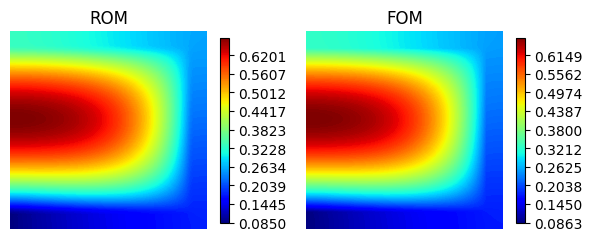

In [110]:
sample = 50
plt.figure(figsize = (7, 3))
plt.subplot(1, 2, 1)
fe.plot(uprova[sample,:], Vh, colorbar = True)
plt.title("ROM")

plt.subplot(1, 2, 2)
fe.plot(u_try[sample,:], Vh, colorbar = True)
plt.title("FOM")


# **Task 3**

In this part I exploit the ROM to find the optimal values of D and $\delta$ that maximize the ratio between efficiency and cost, defined as $$ \delta^*, D^* := \arg \max_{\delta,D} \frac{\text{eff}(\delta, D, d)}{\text{cost}(\delta, D)}$$
Changing the parameters and computing the quantity to maximize for each new parameter instance, the ROM is able to run 10.000 simulations and other computation in less than 10 seconds.

## Optimization through experimental sampling of parameters

In [108]:

delta = 0.05  # 0.05 - 0.1
dpipe = 3 #  1 - 5
dbulk = 0.04 #  0.02 - 0.08 imposed
valueList = []
par1List = []
par2List = []
D = np.linspace(1, 5.0, 100)
delta = np.linspace(0.05,0.1,100)
#D = np.linspace(1, 8, 100)
#delta = np.linspace(0.05,0.2,100)
coordinates = fe.coordinates(Vh)
t0 = perf_counter()
for jjj in delta:
  for iii in D:
    par1List.append(jjj)
    par2List.append(iii)
    # Compute the theta area
    Area_theta=3*jjj-2*jjj**2
    #generate vector of parameters
    mu0t = np.zeros((ntimes, p+1))
    timesteps = CPU.tensor(np.linspace(0, 5.0, ntimes))
    mu0t[:, 3] = timesteps
    mu0 = np.array([jjj,iii,dbulk])
    mu0t[:, :3] = mu0
    MU0t = CPU.tensor(mu0t)
    # compute the ROM solution
    u = model(MU0t) @ V.T
    # compute the efficacy depending on jjj and on ufinalT
    condition1 = coordinates[:,1] > jjj
    condition2 = coordinates[:,1] < 1 - jjj
    condition3 = coordinates[:,0] < 1 - jjj
    mask = condition1 & condition2 & condition3
    ufinalT = u[100,:]
    ufinalT = ufinalT.cpu().numpy()
    eff = (ufinalT[mask] < 0.2).mean()/(1-Area_theta)
    # cost
    cost = iii*(Area_theta)
    obj_fun = eff/cost
    valueList.append(obj_fun)
ccc = np.stack(valueList)
thickness = np.stack(par1List)
k_condotto = np.stack(par2List)
indice_massimo = np.argmax(ccc)
thickness[indice_massimo],k_condotto[indice_massimo]
t1 = perf_counter()
print("simulation time: %.3fs." % (t1-t0))

simulation time: 11.470s.


In [109]:
# @title optimal values
# @markdown The optimal values are the followings. The reason for that is because D enters in the cost linearly, therefore increasing it the denominator increases too much with respect to the numerator and the ratio between efficiency and cost is reduced.
thickness[indice_massimo],k_condotto[indice_massimo]
print("the optimal D is:", k_condotto[indice_massimo])
print("the optimal  δ is:", thickness[indice_massimo])


the optimal D is: 1.0
the optimal  δ is: 0.09393939393939393


## Optimization through gradient descend method

In [107]:

d= 0.04 #  0.02 - 0.08 imposed

import time  # Import the time module


 # Compute the theta area
def Area_theta(theta):
  Area_theta=3*theta-2*theta**2
  return Area_theta

# Objective function
def obj_fun(theta,D,d=0.04):
  #generate vector of parameters
  mu0t = np.zeros((ntimes, p+1))
  timesteps = CPU.tensor(np.linspace(0, 5.0, ntimes))
  mu0t[:, 3] = timesteps
  mu0 = np.array([jjj,iii,dbulk])
  mu0t[:, :3] = mu0
  MU0t = CPU.tensor(mu0t)
  # compute the ROM solution
  u = model(MU0t) @ V.T
  ufinalT = u[100,:]
  ufinalT = ufinalT.cpu().numpy()
  # efficiency
  coordinates = fe.coordinates(Vh)
  condition1 = coordinates[:,1] > jjj
  condition2 = coordinates[:,1] < 1 - jjj
  condition3 = coordinates[:,0] < 1 - jjj
  mask = condition1 & condition2 & condition3
  eff = (ufinalT[mask] < 0.2).mean()/(1-Area_theta(theta))
# cost
  cost = D*(Area_theta(theta))
  obj = eff/cost
  return obj

def compute_gradient(theta, D, d, h=1e-5):
    # Compute the gradient with respect to theta
    theta_plus_h = theta + h
    theta_minus_h = theta - h
    grad_theta = (obj_fun(theta_plus_h, D, d) - obj_fun(theta_minus_h, D, d)) / (2 * h)

    # Compute the gradient with respect to D
    D_plus_h = D + h
    D_minus_h = D - h
    grad_D = (obj_fun(theta, D_plus_h, d) - obj_fun(theta, D_minus_h, d)) / (2 * h)

    return grad_theta, grad_D

theta_bounds=[0.05,0.1]
D_bounds=[1,5]

def project_parameters(theta, D, theta_bounds, D_bounds):
    theta = np.clip(theta, 0.05, 0.1)
    D = np.clip(D, 1, 5)
    return theta, D

# Gradient descent optimization
def optimize(theta_0, D_0, theta_bounds, D_bounds, d=0.04, learning_rate=0.01, num_iterations=100):
    theta = theta_0
    D = D_0
    start_time = time.time()  # Start timing
    for i in range(num_iterations):
        grad_theta, grad_D = compute_gradient(theta, D, d)

        # Update the parameters
        theta -= learning_rate * grad_theta
        D -= learning_rate * grad_D

        # Project parameters back to their bounds
        theta, D = project_parameters(theta, D, theta_bounds, D_bounds)

        # Log the progress
        if i % 10 == 0:
            print(f"Iteration {i}: theta = {theta}, D = {D}, Objective = {obj_fun(theta, D, d)}")

    end_time = time.time()  # End timing

    print(f"Optimization completed in {end_time - start_time:.4f} seconds")  # Print operational time
    return theta, D

# Parameters
theta_0 = 0.1  # Initial guess for δ
D_0 = 0.1  # Initial guess for D
d = 0.04      # Given constant

# Run the optimization
optimal_theta, optimal_D = optimize(theta_0, D_0, d, theta_bounds, D_bounds)

# Print the results
print("Optimal parameters:")
print(f"Optimal theta: {optimal_theta}, Optimal D: {optimal_D}")




Iteration 0: theta = 0.1, D = 5.0, Objective = 0.992063492063492
Iteration 10: theta = 0.1, D = 5.0, Objective = 0.992063492063492
Iteration 20: theta = 0.1, D = 5.0, Objective = 0.992063492063492
Iteration 30: theta = 0.1, D = 5.0, Objective = 0.992063492063492
Iteration 40: theta = 0.1, D = 5.0, Objective = 0.992063492063492
Iteration 50: theta = 0.1, D = 5.0, Objective = 0.992063492063492
Iteration 60: theta = 0.1, D = 5.0, Objective = 0.992063492063492
Iteration 70: theta = 0.1, D = 5.0, Objective = 0.992063492063492
Iteration 80: theta = 0.1, D = 5.0, Objective = 0.992063492063492
Iteration 90: theta = 0.1, D = 5.0, Objective = 0.992063492063492
Optimization completed in 0.8151 seconds
Optimal parameters:
Optimal theta: 0.1, Optimal D: 5.0
